# 🚢 Day 001 - Titanic Survival Prediction

## Problem Statement
The objective of this project is to predict whether a passenger survived the Titanic disaster based on features such as age, sex, passenger class, fare, and more.

## Machine Learning Workflow

- Import Libraries
- Load Dataset
- Data Exploration
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training
- Hyperparameter Tuning
- Cross Validation
- Model Comparison
- Conclusion

📦 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix)

## Load Dataset

In [2]:
df=pd.read_csv('Data/Titanic-Dataset.csv')

## Data Exploration

In [3]:
df.shape

(891, 12)

In [4]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
86,87,0,3,"Ford, Mr. William Neal",male,16.0,1,3,W./C. 6608,34.3750,NaN,S
292,293,0,2,"Levy, Mr. Rene Jacques",male,36.0,0,0,SC/Paris 2163,12.8750,D,C
731,732,0,3,"Hassan, Mr. Houssein G N",male,11.0,0,0,2699,18.7875,NaN,C
548,549,0,3,"Goldsmith, Mr. Frank John",male,33.0,1,1,363291,20.5250,NaN,S
786,787,1,3,"Sjoblom, Miss. Anna Sofia",female,18.0,0,0,3101265,7.4958,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [10]:
df["Survived"].value_counts()
df["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

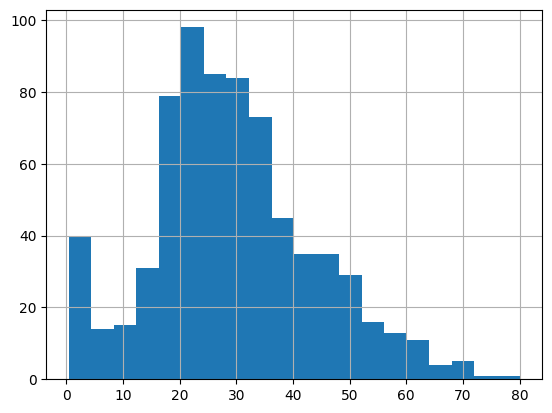

In [11]:
df["Age"].hist(bins=20)
plt.show()

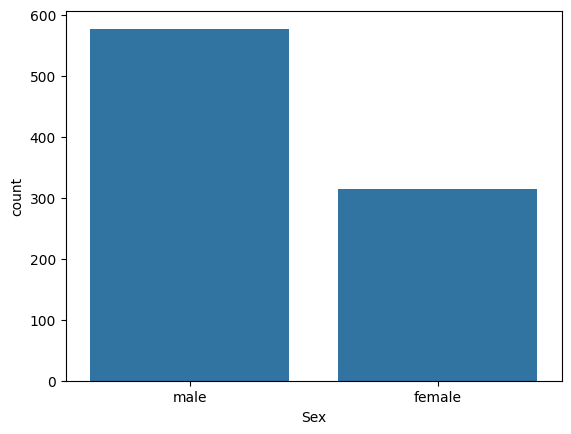

In [12]:
df["Sex"].value_counts()

sns.countplot(x="Sex", data=df)
plt.show()

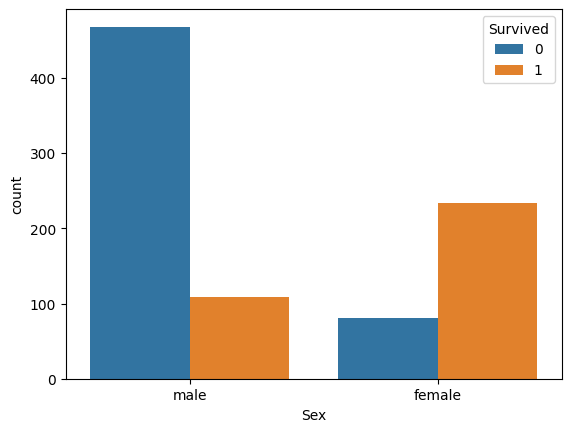

In [13]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.show()

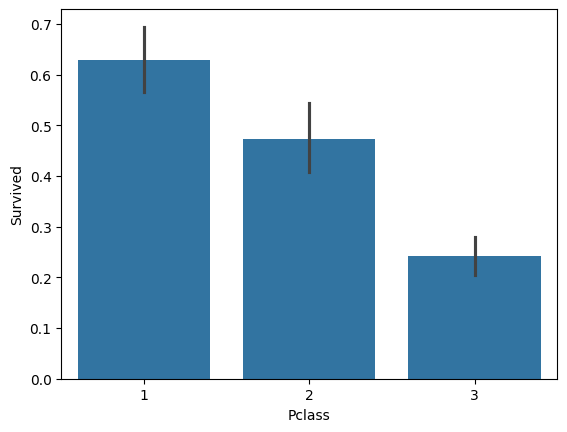

In [14]:
sns.barplot(x="Pclass", y="Survived", data=df)
plt.show()

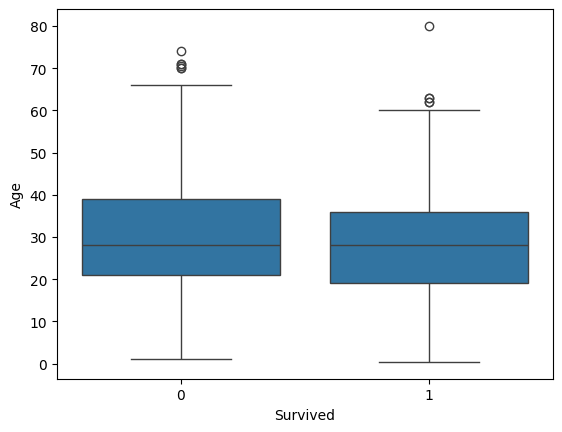

In [15]:
sns.boxplot(x="Survived", y="Age", data=df)
plt.show()

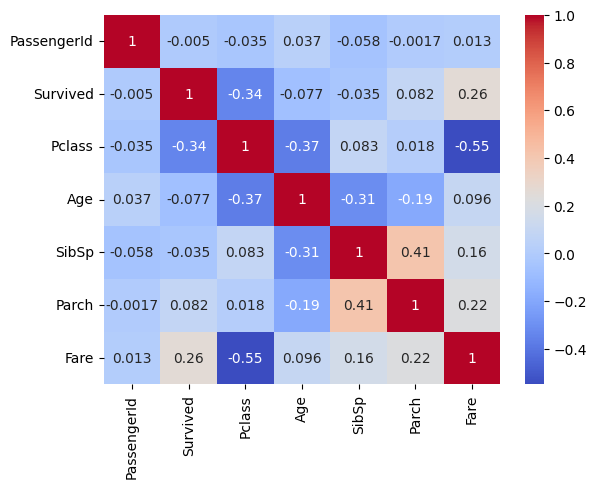

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [17]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [18]:
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
df["Title"].value_counts()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5576\3547909005.py:1: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [19]:
df["Title"] = df["Title"].replace(
    ["Lady", "Countess", "Capt", "Col", "Don", "Dr",
     "Major", "Rev", "Sir", "Jonkheer"],
    "Rare"
)

df["Title"] = df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

In [20]:
df["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

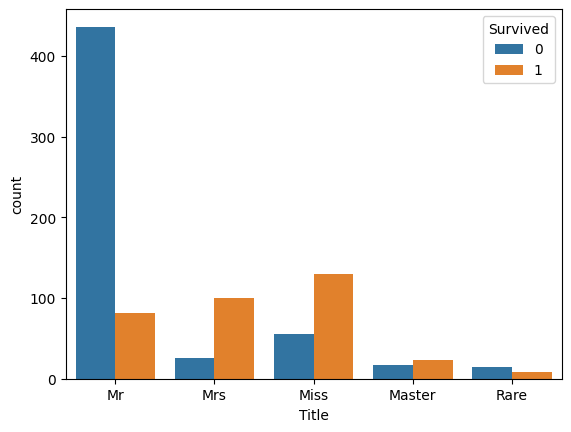

In [21]:
sns.countplot(x="Title", hue="Survived", data=df)
plt.show()

In [22]:
df["Sex"].isnull().sum()


np.int64(0)

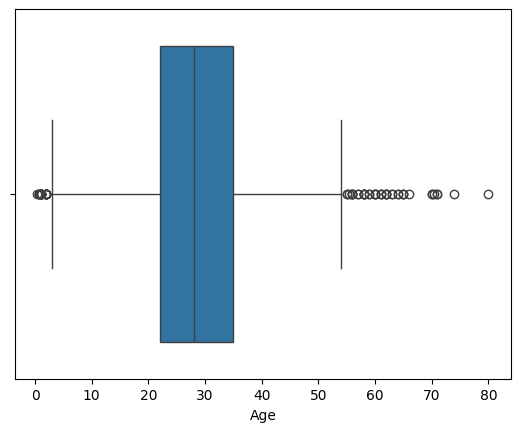

In [23]:
sns.boxplot(x=df["Age"])
plt.show()


In [24]:
df[df["Fare"] == 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,Mr
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,Mr
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,Mr
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,28.0,0,0,239853,0.0,NaN,S,Mr
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,Mr
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,28.0,0,0,239853,0.0,NaN,S,Mr
466,467,0,2,"Campbell, Mr. William",male,28.0,0,0,239853,0.0,NaN,S,Mr
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,28.0,0,0,239854,0.0,NaN,S,Mr
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,Mr
633,634,0,1,"Parr, Mr. William Henry Marsh",male,28.0,0,0,112052,0.0,NaN,S,Mr


In [25]:
df[df["Fare"] == 0]["Pclass"].value_counts()


Pclass
2    6
1    5
3    4
Name: count, dtype: int64

In [26]:
df[df["Fare"] == 0]["Survived"].value_counts(normalize=True) * 100


Survived
0    93.333333
1     6.666667
Name: proportion, dtype: float64

In [27]:
df[df["Fare"] == 0]["Ticket"].value_counts()

Ticket
LINE      4
239853    3
112059    1
239854    1
112052    1
239856    1
239855    1
112050    1
112058    1
19972     1
Name: count, dtype: int64

In [28]:
df.groupby("Title")["Age"].median()

Title
Master     4.0
Miss      24.0
Mr        28.0
Mrs       32.5
Rare      48.0
Name: Age, dtype: float64

In [29]:
df.drop(columns=["Cabin"], inplace=True)

In [30]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
 11  Title        891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [32]:
df = df.dropna()

In [33]:
df["Survived"].value_counts(normalize=True) * 100

Survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64

In [34]:
df["Age"] = df["Age"].astype(int)

In [35]:
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])

In [36]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True, dtype=int)

In [37]:
X = df.drop(["Survived", "Name", "Title","Ticket"], axis=1)
y = df["Survived"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
621,622,1,1,42,1,0,52.5542,0,1
481,482,2,1,28,0,0,0.0000,0,1
527,528,1,1,28,0,0,221.7792,0,1
435,436,1,0,14,1,2,120.0000,0,1
797,798,3,0,31,0,0,8.6833,0,1


In [40]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

scores = cross_val_score(tree, X, y, cv=5, scoring="accuracy")

print(scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

[0.59550562 0.78089888 0.7752809  0.78651685 0.83615819]
Mean Accuracy: 0.7548720878562813
Standard Deviation: 0.08258378408935649


In [41]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3,4, 5, 7, 10, None],
    'min_samples_split': [2,4, 5, 10, 20,40,50],
    'min_samples_leaf': [1, 2, 4, 8],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'ccp_alpha': 0.001, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 20}
Best CV Score: 0.8199940904166256


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [43]:
from sklearn.neighbors import KNeighborsClassifier

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

params = {
    "n_neighbors": [3, 5, 7, 9]
}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_scale, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'n_neighbors': 7}
Best CV Score: 0.8185757904067762


In [45]:
from sklearn.svm import SVC

In [46]:
from sklearn.model_selection import GridSearchCV

params = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    SVC(),
    param_grid=params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_scale, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV Score: 0.812922288978627


In [47]:
from xgboost import XGBClassifier

In [48]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5,6,7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV Score: 0.8340392002363833


In [49]:
best_model = grid.best_estimator_

In [51]:
from sklearn.metrics import accuracy_score

# Training predictions
train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Testing predictions
test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)
print("Difference    :", train_acc - test_acc)

Train Accuracy: 0.8776371308016878
Test Accuracy : 0.8426966292134831
Difference    : 0.03494050158820472


# Conclusion

- Performed data cleaning and preprocessing.
- Built multiple machine learning models.
- Tuned hyperparameters using GridSearchCV.
- Evaluated models using accuracy, precision, recall and F1-score.
- XGBoost achieved the best overall performance.